# Lab 6 — Topic A: LiDAR–camera calibration QA

**Trần Ngọc Khuyến — 2A202602682**

Trong VS Code: **Select Kernel → Colab → Auto Connect → Run All**. CPU là đủ.
Notebook clone dữ liệu public của đề bài, cài snapshot code và chạy benchmark trên 20 KITTI + 80 nuScenes frame.
Không cần push code lên GitHub để chạy snapshot này. Runtime cần Internet để clone/install.
Outputs ban đầu để trống; các con số chỉ được tạo khi kernel chạy thật.

Nguồn: KITTI Vision Benchmark Suite, nuScenes (Motional).


## 1. Kết nối và lấy dữ liệu gốc

In [9]:
import os, sys, subprocess, platform, hashlib
from pathlib import Path

assert platform.system() == 'Linux' and Path('/content').is_dir(), (
    'Chọn Select Kernel > Colab > Auto Connect trước khi Run All. '
    'Notebook này yêu cầu runtime Colab để tránh nhầm số liệu local với remote.')
ROOT = Path('/content/topic_a_lab')
UPSTREAM = 'https://github.com/VinUni-AI20k/K4-Track4-Day06-3D-From-Point-Clouds.git'
if not (ROOT / '.git').is_dir():
    assert not ROOT.exists(), 'Thư mục /content/topic_a_lab đã tồn tại nhưng không phải repo; đổi ROOT.'
    subprocess.run(['git', 'clone', '--depth', '1', UPSTREAM, str(ROOT)], check=True)
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

DATA_MANIFEST_SHA256 = {'kitti_mini': '3b3d8fedd412234c882204226a72d225d728be4f1f5cd8a083131e0d35e95228', 'nuscenes_mini_subset': '843d9c6e3d1524aefb5d8f766ff71b085f273d2ab321434baf81dd60a38f9d1f'}

for dataset, expected in DATA_MANIFEST_SHA256.items():
    actual = hashlib.sha256((ROOT / 'data' / dataset / 'MANIFEST.json').read_bytes()).hexdigest()
    assert actual == expected, f'Dataset {dataset} khác snapshot local; kiểm tra trước khi benchmark.'
print('Colab runtime:', platform.platform(), sys.version)
print('Working directory:', ROOT)

Colab runtime: Linux-6.6.122+-x86_64-with-glibc2.39 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Working directory: /content/topic_a_lab


## 2. Cài snapshot code và thư viện
Cell dài chứa toàn bộ code cần thiết để runtime remote không dùng nhầm bản starter chưa sửa.

In [10]:
STUDENT_FILES = {'starter/projection.py': '"""LiDAR -> camera projection, overlay và perturb calibration.\n\nHai hàm có `TODO(CP2)` là phần học viên phải tự cài đặt (bắt buộc cho topic A, C, F;\nkhuyến khích cho mọi topic vì đây là bài test calibration rẻ nhất).\n\nChạy thử sau khi cài đặt xong (cùng một code chạy được cho cả KITTI và nuScenes):\n    python -m starter.projection --data-root data/synthetic --frame 000000\n    python -m starter.projection --data-root data/synthetic --frame 000000 --yaw-deg 1.0\n    python -m starter.projection --data-root data/kitti_mini --frame 000011\n    python -m starter.projection --data-root data/nuscenes_mini_subset --frame scene-0103_010\n    python -m starter.projection --data-root data/nuscenes_mini_subset --frame scene-0103_010 --ignore-ego-motion\n"""\nfrom __future__ import annotations\n\nimport argparse\nimport copy\nfrom pathlib import Path\n\nimport cv2\nimport numpy as np\n\nfrom starter.datasets import dataset_type, load_frame\nfrom starter.kitti_io import KittiCalib, KittiObject\n\n\ndef velo_to_cam(points_xyz: np.ndarray, calib: KittiCalib) -> np.ndarray:\n    """Đưa điểm (N, 3) từ velodyne frame sang rectified camera frame (N, 3).\n\n    TODO(CP2):\n      1. Chuyển sang toạ độ đồng nhất (N, 4).\n      2. Nhân với calib.T_cam_velo (4x4). Chú ý chiều nhân và transpose.\n      3. Trả về 3 cột đầu.\n    Tự kiểm: một điểm velodyne (10, 0, 0) phải có z_cam ~ 10 (phía trước camera).\n    """\n    xyz = np.asarray(points_xyz, dtype=np.float64)\n    if xyz.ndim != 2 or xyz.shape[1] != 3:\n        raise ValueError("points_xyz phải có shape (N, 3)")\n    valid = np.isfinite(xyz).all(axis=1)\n    camera = np.full(xyz.shape, np.nan, dtype=np.float64)\n    homogeneous = np.column_stack([xyz[valid], np.ones(valid.sum())])\n    camera[valid] = (homogeneous @ calib.T_cam_velo.T)[:, :3]\n    return camera\n\n\ndef cam_to_image(points_cam: np.ndarray, P2: np.ndarray, image_shape: tuple[int, ...],\n                 min_depth: float = 0.1) -> tuple[np.ndarray, np.ndarray, np.ndarray]:\n    """Chiếu điểm camera frame (N, 3) lên ảnh bằng P2 (3x4).\n\n    Trả về:\n      uv    (M, 2) toạ độ pixel của các điểm hợp lệ\n      depth (M,)   z_cam của các điểm hợp lệ\n      mask  (N,)   bool, True nếu điểm hợp lệ\n\n    Điểm hợp lệ = depth > min_depth VÀ nằm trong ảnh (0 <= u < W, 0 <= v < H).\n\n    TODO(CP2):\n      1. Lọc điểm không hợp lệ (NaN/Inf): dữ liệu thật không bao giờ sạch.\n      2. Toạ độ đồng nhất, nhân P2 -> (N, 3) = [s*u, s*v, s].\n      3. Chia cho s để có (u, v). Chỉ chia với điểm có depth > min_depth.\n      4. Lọc theo kích thước ảnh image_shape[:2] = (H, W).\n    """\n    camera = np.asarray(points_cam, dtype=np.float64)\n    if camera.ndim != 2 or camera.shape[1] != 3:\n        raise ValueError("points_cam phải có shape (N, 3)")\n    height, width = image_shape[:2]\n    mask = np.zeros(len(camera), dtype=bool)\n    candidates = np.flatnonzero(np.isfinite(camera).all(axis=1)\n                                & (camera[:, 2] > min_depth))\n    homogeneous = np.column_stack([camera[candidates], np.ones(len(candidates))])\n    projected = homogeneous @ np.asarray(P2, dtype=np.float64).T\n    usable = np.isfinite(projected).all(axis=1) & (projected[:, 2] > 1e-12)\n    candidates, projected = candidates[usable], projected[usable]\n    uv = projected[:, :2] / projected[:, 2:3]\n    inside = ((uv[:, 0] >= 0) & (uv[:, 0] < width)\n              & (uv[:, 1] >= 0) & (uv[:, 1] < height))\n    mask[candidates[inside]] = True\n    return uv[inside], camera[mask, 2], mask\n\n\ndef project_velo_to_image(points: np.ndarray, calib: KittiCalib, image_shape: tuple[int, ...]):\n    """points (N, >=3) velodyne -> (uv, depth, mask) như `cam_to_image`."""\n    return cam_to_image(velo_to_cam(points[:, :3], calib), calib.P2, image_shape)\n\n\ndef overlay_points(image: np.ndarray, uv: np.ndarray, depth: np.ndarray,\n                   max_depth: float = 50.0, radius: int = 2) -> np.ndarray:\n    """Vẽ điểm lên ảnh, màu theo depth (gần = đỏ, xa = xanh)."""\n    out = image.copy()\n    d = np.clip(depth / max_depth, 0, 1)\n    colors = cv2.applyColorMap((255 * (1 - d)).astype(np.uint8).reshape(-1, 1), cv2.COLORMAP_JET)\n    for (u, v), c in zip(uv.astype(int), colors[:, 0]):\n        cv2.circle(out, (int(u), int(v)), radius, tuple(int(x) for x in c), -1)\n    return out\n\n\ndef _rot(roll: float, pitch: float, yaw: float) -> np.ndarray:\n    cr, sr, cp, sp, cy, sy = np.cos(roll), np.sin(roll), np.cos(pitch), np.sin(pitch), np.cos(yaw), np.sin(yaw)\n    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])\n    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])\n    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])\n    return Rz @ Ry @ Rx\n\n\ndef perturb_extrinsic(calib: KittiCalib, roll_deg: float = 0.0, pitch_deg: float = 0.0,\n                      yaw_deg: float = 0.0, t_xyz_m: tuple[float, float, float] = (0, 0, 0)) -> KittiCalib:\n    """Giả lập calibration drift: xoay/dịch LiDAR trong chính velodyne frame\n    (yaw quanh z-up, pitch quanh y-left, roll quanh x-forward) rồi ghép vào Tr_velo_to_cam."""\n    D = np.eye(4)\n    D[:3, :3] = _rot(*np.deg2rad([roll_deg, pitch_deg, yaw_deg]))\n    D[:3, 3] = t_xyz_m\n    Tr = np.eye(4)\n    Tr[:3, :] = calib.Tr_velo_to_cam\n    out = copy.deepcopy(calib)\n    out.Tr_velo_to_cam = (Tr @ D)[:3, :]\n    return out\n\n\ndef box3d_corners_cam(obj: KittiObject) -> np.ndarray:\n    """8 góc (8, 3) của box KITTI trong rectified camera frame.\n    Thứ tự: 4 góc đáy (y=0) rồi 4 góc nóc (y=-h)."""\n    h, w, l = obj.dimensions\n    x = np.array([l, l, -l, -l, l, l, -l, -l]) / 2\n    y = np.array([0, 0, 0, 0, -h, -h, -h, -h])\n    z = np.array([w, -w, -w, w, w, -w, -w, w]) / 2\n    c, s = np.cos(obj.rotation_y), np.sin(obj.rotation_y)\n    R = np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])\n    return (R @ np.vstack([x, y, z])).T + obj.location\n\n\ndef draw_box2d(image: np.ndarray, bbox, color=(0, 255, 0), label: str | None = None) -> np.ndarray:\n    out = image.copy()\n    x1, y1, x2, y2 = (int(round(v)) for v in bbox)\n    cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)\n    if label:\n        cv2.putText(out, label, (x1, max(0, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)\n    return out\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser(description="Chiếu điểm LiDAR lên ảnh camera, tô màu theo độ sâu, vẽ 2D box của label")\n    ap.add_argument("--data-root", default="data/synthetic",\n                    help="thư mục KITTI (data/synthetic, data/kitti_mini) hoặc nuScenes (data/nuscenes_mini_subset)")\n    ap.add_argument("--frame", default="000000", help="KITTI: 000011. nuScenes: scene-0103_010")\n    ap.add_argument("--out-dir", default="results/figures", help="nơi lưu ảnh overlay")\n    ap.add_argument("--roll-deg", type=float, default=0.0, help="giả lập LiDAR bị xoay quanh trục x (độ)")\n    ap.add_argument("--pitch-deg", type=float, default=0.0, help="giả lập LiDAR bị xoay quanh trục y (độ)")\n    ap.add_argument("--yaw-deg", type=float, default=0.0, help="giả lập LiDAR bị xoay quanh trục z hướng lên (độ)")\n    ap.add_argument("--tx", type=float, default=0.0, help="giả lập LiDAR bị dịch theo trục x của LiDAR (mét)")\n    ap.add_argument("--ty", type=float, default=0.0, help="giả lập LiDAR bị dịch theo trục y của LiDAR (mét)")\n    ap.add_argument("--tz", type=float, default=0.0, help="giả lập LiDAR bị dịch theo trục z của LiDAR (mét)")\n    ap.add_argument("--ignore-ego-motion", action="store_true",\n                    help="chỉ cho nuScenes: bỏ bù chuyển động xe giữa thời điểm chụp LiDAR và camera")\n    args = ap.parse_args()\n\n    kwargs = {"use_ego_motion": not args.ignore_ego_motion} if dataset_type(args.data_root) == "nuscenes" else {}\n    fr = load_frame(args.data_root, args.frame, **kwargs)\n    calib = perturb_extrinsic(fr["calib"], args.roll_deg, args.pitch_deg, args.yaw_deg,\n                              (args.tx, args.ty, args.tz))\n    uv, depth, mask = project_velo_to_image(fr["points"], calib, fr["image"].shape)\n    vis = overlay_points(fr["image"], uv, depth)\n    for obj in fr["labels"]:\n        vis = draw_box2d(vis, obj.bbox, label=obj.type)\n\n    tag = f"r{args.roll_deg}_p{args.pitch_deg}_y{args.yaw_deg}_t{args.tx}_{args.ty}_{args.tz}"\n    if args.ignore_ego_motion:\n        tag += "_noego"\n    out = Path(args.out_dir) / f"overlay_{args.frame}_{tag}.png"\n    out.parent.mkdir(parents=True, exist_ok=True)\n    cv2.imwrite(str(out), vis)\n    print(f"points={len(mask)} inside_image={int(mask.sum())} ({mask.mean():.1%}) -> {out}")\n\n\nif __name__ == "__main__":\n    main()\n', 'src/__init__.py': '"""Student implementation for Topic A, Day 6 Lab."""\n', 'src/topic_a.py': '"""Calibration QA with fixed object point sets and reproducible one-factor sweeps.\n\nRun: python -m src.topic_a --help\nGeometry conventions come from the provided starter/kitti_io.py and projection.py.\nAll measurements are computed from original data; no source data are overwritten.\n"""\nfrom __future__ import annotations\n\nimport argparse\nimport hashlib\nimport json\nimport platform\nimport sys\nfrom pathlib import Path\n\nimport cv2\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\n\nfrom starter.datasets import list_frames, load_frame\nfrom starter.projection import (draw_box2d, overlay_points, perturb_extrinsic,\n                                project_velo_to_image, velo_to_cam)\n\n\ndef points_in_box(camera_xyz, obj):\n    """Undo camera yaw; KITTI location is bottom center, local y lies in [-h, 0]."""\n    h, w, length = obj.dimensions\n    c, s = np.cos(obj.rotation_y), np.sin(obj.rotation_y)\n    rotation = np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])\n    local = (camera_xyz - obj.location) @ rotation\n    return (np.isfinite(local).all(axis=1)\n            & (np.abs(local[:, 0]) <= length / 2 + 1e-6)\n            & (local[:, 1] >= -h - 1e-6) & (local[:, 1] <= 1e-6)\n            & (np.abs(local[:, 2]) <= w / 2 + 1e-6))\n\n\ndef configurations(dataset):\n    """Each entry changes one axis; all other components stay at zero."""\n    configs = [(\'yaw_deg\', v) for v in [-3, -2, -1, -.5, 0, .5, 1, 2, 3]]\n    if dataset == \'kitti\':\n        configs += [(\'pitch_deg\', v) for v in [0, .5, 1, 2, 3]]\n        configs += [(\'roll_deg\', v) for v in [0, 1, 2, 3]]\n        configs += [(\'ty_m\', v) for v in [-.1, -.05, -.02, 0, .02, .05, .1]]\n    return configs\n\n\ndef drifted(calib, factor, value):\n    if factor == \'ty_m\':\n        return perturb_extrinsic(calib, t_xyz_m=(0, value, 0))\n    return perturb_extrinsic(calib, **{factor: value})\n\n\ndef indexed_projection(points, calib, image_shape):\n    uv, depth, mask = project_velo_to_image(points, calib, image_shape)\n    indexed = np.full((len(points), 2), np.nan)\n    indexed[mask] = uv\n    return indexed, uv, depth, mask\n\n\ndef in_image_box(uv, bbox):\n    x1, y1, x2, y2 = bbox\n    return (np.isfinite(uv).all(axis=1) & (uv[:, 0] >= x1)\n            & (uv[:, 0] <= x2) & (uv[:, 1] >= y1) & (uv[:, 1] <= y2))\n\n\ndef selected_objects(fr, min_points):\n    reference_cam = velo_to_cam(fr[\'points\'][:, :3], fr[\'calib\'])\n    objects = []\n    for number, obj in enumerate(fr[\'labels\']):\n        if not (np.isfinite(obj.dimensions).all() and (obj.dimensions > 0).all()\n                and np.isfinite(obj.location).all() and np.isfinite(obj.rotation_y)\n                and np.isfinite(obj.bbox).all()):\n            continue\n        indices = np.flatnonzero(points_in_box(reference_cam, obj))\n        if len(indices) >= min_points:\n            objects.append((number, obj, indices))\n    return objects\n\n\ndef experiment(root, dataset, min_points, frame_limit=None):\n    frames = list_frames(root)\n    if frame_limit:\n        frames = frames[:frame_limit]\n    frame_rows, object_rows = [], []\n    for fid in frames:\n        fr = load_frame(root, fid)\n        objects = selected_objects(fr, min_points)\n        baseline_uv, _, _, _ = indexed_projection(fr[\'points\'], fr[\'calib\'], fr[\'image\'].shape)\n        n_finite = int(np.isfinite(fr[\'points\'][:, :3]).all(axis=1).sum())\n        for factor, value in configurations(dataset):\n            calib = drifted(fr[\'calib\'], factor, value)\n            indexed, _, _, mask = indexed_projection(fr[\'points\'], calib, fr[\'image\'].shape)\n            ratios, total_inside, total_points, displacement = [], 0, 0, []\n            for number, obj, indices in objects:\n                inside = int(in_image_box(indexed[indices], obj.bbox).sum())\n                ratio = inside / len(indices)\n                pair_ok = (np.isfinite(indexed[indices]).all(axis=1)\n                           & np.isfinite(baseline_uv[indices]).all(axis=1))\n                delta = np.linalg.norm(indexed[indices][pair_ok] - baseline_uv[indices][pair_ok], axis=1)\n                displacement.extend(delta.tolist())\n                ratios.append(ratio)\n                total_inside += inside\n                total_points += len(indices)\n                object_rows.append(dict(dataset=dataset, frame_id=fid, factor=factor, value=value,\n                                        object_id=number, class_name=obj.type,\n                                        range_m=float(np.linalg.norm(obj.location)),\n                                        depth_m=float(obj.location[2]), occluded=obj.occluded,\n                                        truncated=obj.truncated, reference_points=len(indices),\n                                        inside_box_points=inside, inside_box_pct=100 * ratio,\n                                        median_shift_px=float(np.median(delta)) if len(delta) else np.nan))\n            frame_rows.append(dict(dataset=dataset, frame_id=fid, factor=factor, value=value,\n                                   finite_points=n_finite, fov_points=int(mask.sum()),\n                                   fov_pct=100 * mask.sum() / n_finite if n_finite else np.nan,\n                                   eligible_objects=len(objects), object_points=total_points,\n                                   inside_box_points=total_inside,\n                                   macro_box_pct=100 * np.mean(ratios) if ratios else np.nan,\n                                   micro_box_pct=100 * total_inside / total_points if total_points else np.nan,\n                                   median_shift_px=float(np.median(displacement)) if displacement else np.nan))\n        print(f\'{dataset}/{fid}: {len(objects)} eligible objects\', flush=True)\n    return frame_rows, object_rows\n\n\ndef summarize(frames, objects):\n    rows = []\n    for (dataset, factor, value), group in frames.groupby([\'dataset\', \'factor\', \'value\'], sort=True):\n        selected = objects[(objects.dataset == dataset) & (objects.factor == factor) & (objects.value == value)]\n        total_points = int(group.object_points.sum())\n        rows.append(dict(dataset=dataset, factor=factor, value=value, n_frames=len(group),\n                         eligible_objects=int(group.eligible_objects.sum()),\n                         fov_pct=100 * group.fov_points.sum() / group.finite_points.sum(),\n                         macro_box_pct=selected.inside_box_pct.mean(),\n                         micro_box_pct=100 * group.inside_box_points.sum() / total_points if total_points else np.nan,\n                         median_frame_shift_px=group.median_shift_px.median()))\n    return pd.DataFrame(rows)\n\n\ndef detection(frames, out):\n    """Learn one absolute score threshold from clean calibration frames only.\n\n    Lexicographic split: first half of KITTI frames calibrates the threshold;\n    remaining frames evaluate all yaw levels. Reference GT is an offline diagnostic.\n    """\n    yaw = frames[(frames.dataset == \'kitti\') & (frames.factor == \'yaw_deg\')].copy()\n    ids = sorted(yaw.frame_id.unique())\n    calibration_ids = ids[:len(ids) // 2]\n    evaluation_ids = ids[len(ids) // 2:]\n    clean_scores = yaw[(yaw.frame_id.isin(calibration_ids)) & (yaw.value == 0)].macro_box_pct.dropna()\n    if clean_scores.empty or not evaluation_ids:\n        raise ValueError(\'Need at least two KITTI frames with eligible objects for threshold evaluation\')\n    threshold = float(np.percentile(clean_scores, 5))\n    yaw[\'split\'] = np.where(yaw.frame_id.isin(calibration_ids), \'calibration\', \'evaluation\')\n    yaw[\'threshold_pct\'] = threshold\n    yaw[\'has_score\'] = yaw.macro_box_pct.notna()\n    yaw[\'alarm\'] = yaw.macro_box_pct.lt(threshold) & yaw.has_score\n    yaw.to_csv(out / \'drift_detection.csv\', index=False, float_format=\'%.8f\')\n    eval_rows = yaw[yaw.split == \'evaluation\']\n    rows = []\n    for value, group in eval_rows.groupby(\'value\'):\n        usable = group[group.has_score]\n        rows.append(dict(yaw_deg=value, n_scored=len(usable), n_unscored=len(group) - len(usable),\n                         alarm_rate_pct=100 * usable.alarm.mean(), threshold_pct=threshold))\n    pd.DataFrame(rows).to_csv(out / \'detection_summary.csv\', index=False, float_format=\'%.8f\')\n    return yaw, threshold, calibration_ids, evaluation_ids\n\n\ndef plots(summary, objects, detected, threshold, figures):\n    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)\n    for dataset, group in summary[summary.factor == \'yaw_deg\'].groupby(\'dataset\'):\n        group = group.sort_values(\'value\')\n        for axis, metric, title in zip(axes,\n                [\'macro_box_pct\', \'fov_pct\', \'median_frame_shift_px\'],\n                [\'Object alignment (equal object weight)\', \'Points inside image\', \'Projected object point displacement\']):\n            axis.plot(group.value, group[metric], \'o-\', label=dataset)\n            axis.set(title=title, xlabel=\'LiDAR yaw drift (degrees)\', ylabel=\'%\' if metric != \'median_frame_shift_px\' else \'pixels\')\n            axis.grid(alpha=.3)\n            axis.legend()\n    fig.savefig(figures / \'yaw_sweep.png\', dpi=140)\n    plt.close(fig)\n    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)\n    for axis, factor in zip(axes, [\'pitch_deg\', \'roll_deg\', \'ty_m\']):\n        group = summary[(summary.dataset == \'kitti\') & (summary.factor == factor)].sort_values(\'value\')\n        axis.plot(group.value, group.macro_box_pct, \'o-\')\n        axis.set(title=f\'KITTI: {factor}\', xlabel=\'meters\' if factor == \'ty_m\' else \'degrees\', ylabel=\'Object alignment (%)\')\n        axis.grid(alpha=.3)\n    fig.savefig(figures / \'other_axes.png\', dpi=140)\n    plt.close(fig)\n    selected = objects[(objects.dataset == \'kitti\') & (objects.factor == \'yaw_deg\')].copy()\n    selected[\'range_group\'] = pd.cut(selected.depth_m, [0, 15, 30, float(\'inf\')], labels=[\'0-15 m\', \'15-30 m\', \'>30 m\'])\n    grouped = selected.groupby([\'range_group\', \'value\'], observed=True).inside_box_pct.mean().reset_index()\n    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)\n    for group_name, group in grouped.groupby(\'range_group\', observed=True):\n        axes[0].plot(group.value, group.inside_box_pct, \'o-\', label=str(group_name))\n    axes[0].set(title=\'KITTI alignment by camera depth\', xlabel=\'Yaw (degrees)\', ylabel=\'Object alignment (%)\')\n    axes[0].legend()\n    for class_name in [\'Car\', \'Pedestrian\', \'Cyclist\']:\n        group = selected[selected.class_name == class_name].groupby(\'value\').inside_box_pct.mean()\n        if len(group):\n            axes[1].plot(group.index, group.values, \'o-\', label=class_name)\n    axes[1].set(title=\'KITTI alignment by class\', xlabel=\'Yaw (degrees)\', ylabel=\'Object alignment (%)\')\n    axes[1].legend()\n    for axis in axes:\n        axis.grid(alpha=.3)\n    fig.savefig(figures / \'range_class_sweep.png\', dpi=140)\n    plt.close(fig)\n    fig, axis = plt.subplots(figsize=(8, 4), constrained_layout=True)\n    evaluation = detected[detected.split == \'evaluation\']\n    for fid, group in evaluation.groupby(\'frame_id\'):\n        axis.plot(group.value, group.macro_box_pct, alpha=.55, label=fid)\n    axis.axhline(threshold, color=\'red\', linestyle=\'--\', label=f\'Clean-only threshold = {threshold:.2f}%\')\n    axis.set(title=\'KITTI held-out drift detection\', xlabel=\'Yaw (degrees)\', ylabel=\'Frame alignment score (%)\')\n    axis.grid(alpha=.3)\n    axis.legend(ncol=3, fontsize=7)\n    fig.savefig(figures / \'drift_threshold.png\', dpi=140)\n    plt.close(fig)\n\n\ndef display_overlay(fr, value=0):\n    uv, depth, _ = project_velo_to_image(fr[\'points\'], drifted(fr[\'calib\'], \'yaw_deg\', value), fr[\'image\'].shape)\n    vis = overlay_points(fr[\'image\'], uv, depth, radius=1)\n    for obj in fr[\'labels\']:\n        vis = draw_box2d(vis, obj.bbox, label=obj.type)\n    return vis\n\n\ndef demos(root, figures):\n    """Three explicitly measured object depths: nearest eligible car in each frame."""\n    rows = []\n    for fid in [\'000019\', \'000011\', \'000004\']:\n        if fid not in list_frames(root):\n            continue\n        fr = load_frame(root, fid)\n        eligible = [(num, obj, indices) for num, obj, indices in selected_objects(fr, 5) if obj.type == \'Car\']\n        if not eligible:\n            eligible = selected_objects(fr, 5)\n        num, obj, _ = min(eligible, key=lambda item: item[1].location[2])\n        vis = display_overlay(fr)\n        vis = draw_box2d(vis, obj.bbox, color=(0, 0, 255), label=f\'Target depth {obj.location[2]:.1f} m\')\n        cv2.imwrite(str(figures / f\'overlay_{fid}.png\'), vis)\n        rows.append(dict(frame_id=fid, object_id=num, class_name=obj.type, depth_m=float(obj.location[2])))\n    return rows\n\n\ndef failure_figure(root, row, figures, filename, title, threshold):\n    fr = load_frame(root, row.frame_id)\n    fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)\n    for axis, value in zip(axes, [0, row.value]):\n        axis.imshow(cv2.cvtColor(display_overlay(fr, value), cv2.COLOR_BGR2RGB))\n        axis.set_title(f\'{row.frame_id}: yaw {value:+g} degrees\')\n        axis.axis(\'off\')\n    fig.suptitle(f\'{title}\\nScore {row.macro_box_pct:.2f}% vs threshold {threshold:.2f}%; FOV {row.fov_pct:.2f}%\')\n    fig.savefig(figures / filename, dpi=130)\n    plt.close(fig)\n\n\ndef main():\n    parser = argparse.ArgumentParser(description=__doc__,\n                                     formatter_class=argparse.ArgumentDefaultsHelpFormatter)\n    parser.add_argument(\'--kitti-root\', default=\'data/kitti_mini\', help=\'KITTI dataset directory\')\n    parser.add_argument(\'--nuscenes-root\', default=\'data/nuscenes_mini_subset\', help=\'nuScenes subset directory\')\n    parser.add_argument(\'--skip-nuscenes\', action=\'store_true\', help=\'Run KITTI only; omits the B5 comparison\')\n    parser.add_argument(\'--out-dir\', default=\'results\', help=\'Directory for CSVs, plots, overlays and run metadata\')\n    parser.add_argument(\'--min-object-points\', type=int, default=5, help=\'Minimum reference LiDAR points per eligible GT object\')\n    parser.add_argument(\'--frame-limit\', type=int, default=None, help=\'Optional smoke-run limit; omit for submission\')\n    parser.add_argument(\'--seed\', type=int, default=42, help=\'Seed recorded for reproducibility\')\n    args = parser.parse_args()\n    if args.min_object_points < 1:\n        parser.error(\'--min-object-points must be positive\')\n    np.random.seed(args.seed)\n    out = Path(args.out_dir)\n    figures = out / \'figures\'\n    figures.mkdir(parents=True, exist_ok=True)\n    rows, objs = experiment(args.kitti_root, \'kitti\', args.min_object_points, args.frame_limit)\n    if not args.skip_nuscenes:\n        extra_rows, extra_objs = experiment(args.nuscenes_root, \'nuscenes\', args.min_object_points, args.frame_limit)\n        rows.extend(extra_rows)\n        objs.extend(extra_objs)\n    frames, objects = pd.DataFrame(rows), pd.DataFrame(objs)\n    if objects.empty:\n        raise ValueError(\'No eligible object points; check dataset and --min-object-points\')\n    summary = summarize(frames, objects)\n    for name, table in [(\'frame_metrics\', frames), (\'object_metrics\', objects), (\'sweep_summary\', summary)]:\n        table.to_csv(out / f\'{name}.csv\', index=False, float_format=\'%.8f\')\n    detected, threshold, calibration_ids, evaluation_ids = detection(frames, out)\n    plots(summary, objects, detected, threshold, figures)\n    demo_rows = demos(args.kitti_root, figures)\n    pd.DataFrame(demo_rows).to_csv(out / \'demo_depths.csv\', index=False, float_format=\'%.8f\')\n    evaluation = detected[(detected.split == \'evaluation\') & (detected.value != 0) & detected.has_score]\n    worst = evaluation.sort_values(\'macro_box_pct\').iloc[0]\n    failure_figure(args.kitti_root, worst, figures, \'fail_01_large_drift.png\', \'Geometry failure: displaced object points\', threshold)\n    missed = evaluation[(~evaluation.alarm) & (evaluation.value.abs() >= .5)]\n    if len(missed):\n        # Show the largest missed drift, then the largest measured pixel shift.\n        selected_failure = missed.assign(abs_yaw=missed.value.abs()).sort_values(\n            [\'abs_yaw\', \'median_shift_px\'], ascending=False).iloc[0].drop(\'abs_yaw\')\n    else:\n        selected_failure = worst\n    failure_figure(args.kitti_root, selected_failure, figures, \'fail_02_score_blind_spot.png\',\n                   \'Metric failure: nonzero drift below alarm sensitivity\' if len(missed) else \'Metric limitation example\', threshold)\n    clean_false_alarms = detected[(detected.split == \'evaluation\') & (detected.value == 0) & detected.alarm]\n    if len(clean_false_alarms):\n        failure_figure(args.kitti_root, clean_false_alarms.iloc[0], figures, \'fail_03_clean_false_alarm.png\',\n                       \'Metric failure: clean frame triggers alarm\', threshold)\n    metadata = dict(seed=args.seed, platform=platform.platform(), python=sys.version,\n                    versions=dict(numpy=np.__version__, opencv=cv2.__version__, pandas=pd.__version__, matplotlib=matplotlib.__version__),\n                    runtime=\'google_colab\' if Path(\'/content\').exists() and platform.system() == \'Linux\' else \'local\',\n                    min_object_points=args.min_object_points, frame_limit=args.frame_limit,\n                    datasets=dict(kitti=args.kitti_root, nuscenes=None if args.skip_nuscenes else args.nuscenes_root),\n                    threshold_pct=threshold, threshold_method=\'5th percentile of clean first-half KITTI frame scores; alarm score < threshold\',\n                    calibration_ids=calibration_ids, evaluation_ids=evaluation_ids,\n                    geometry_failure=worst.to_dict(), metric_failure=selected_failure.to_dict(),\n                    actual_missed_detection=bool(len(missed)), clean_false_alarm_frames=clean_false_alarms.frame_id.tolist(),\n                    demo_depths=demo_rows,\n                    sources=[\'KITTI Vision Benchmark Suite\', \'nuScenes (Motional)\'],\n                    csv_sha256={p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(out.glob(\'*.csv\'))})\n    (out / \'run_metadata.json\').write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding=\'utf-8\')\n    print(\'\\n\' + summary.to_string(index=False), flush=True)\n    print(f\'\\nThreshold: {threshold:.4f}%; missed detection found: {bool(len(missed))}\', flush=True)\n\n\nif __name__ == \'__main__\':\n    main()\n', 'src/test_projection.py': '"""Independent geometry checks: python -m unittest src.test_projection -v."""\nimport unittest\n\nimport numpy as np\n\nfrom starter.kitti_io import KittiCalib, KittiObject, load_calib\nfrom starter.projection import cam_to_image, velo_to_cam\n\n\nclass ProjectionTests(unittest.TestCase):\n    def test_rigid_transform_and_rectification_order(self):\n        rect = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1.]])\n        extrinsic = np.column_stack([np.eye(3), [1, 2, 3]])\n        calibration = KittiCalib(np.zeros((3, 4)), rect, extrinsic)\n        np.testing.assert_allclose(velo_to_cam(np.array([[4, 5, 6.]]), calibration),\n                                   [[-7, 5, 9]])\n\n    def test_mask_depth_nonfinite_and_image_boundaries(self):\n        projection = np.column_stack([np.eye(3), np.zeros(3)])\n        points = np.array([[1, 2, 1], [0, 0, 1], [10, 2, 1], [2, 8, 1],\n                           [-1, 2, 1], [1, 2, -1], [1, 2, 0],\n                           [np.nan, 2, 1], [1, np.inf, 1], [1, 2, .1]])\n        uv, depth, mask = cam_to_image(points, projection, (8, 10, 3))\n        np.testing.assert_array_equal(mask, [True, True] + [False] * 8)\n        np.testing.assert_allclose(uv, [[1, 2], [0, 0]])\n        np.testing.assert_allclose(depth, [1, 1])\n\n    def test_projection_uses_fourth_column(self):\n        projection = np.column_stack([np.eye(3), [4, 6, 0]])\n        uv, _, _ = cam_to_image(np.array([[2, 4, 2]]), projection, (20, 20))\n        np.testing.assert_allclose(uv, [[3, 5]])\n\n    def test_empty_cloud_and_invalid_lidar(self):\n        calibration = KittiCalib(np.column_stack([np.eye(3), np.zeros(3)]),\n                                np.eye(3), np.column_stack([np.eye(3), np.zeros(3)]))\n        self.assertEqual(velo_to_cam(np.empty((0, 3)), calibration).shape, (0, 3))\n        camera = velo_to_cam(np.array([[np.inf, 0, 1], [1, 2, 3]]), calibration)\n        self.assertTrue(np.isnan(camera[0]).all())\n        uv, depth, mask = cam_to_image(np.empty((0, 3)), calibration.P2, (10, 10))\n        self.assertEqual((uv.shape, depth.shape, mask.shape), ((0, 2), (0,), (0,)))\n\n    def test_synthetic_reference_point(self):\n        calibration = load_calib(\'data/synthetic/training/calib/000000.txt\')\n        camera = velo_to_cam(np.array([[10, 0, 0]]), calibration)\n        uv, _, mask = cam_to_image(camera, calibration.P2, (375, 1242, 3))\n        self.assertTrue(mask[0])\n        self.assertAlmostEqual(camera[0, 2], 9.73, delta=.03)\n        np.testing.assert_allclose(uv, [[614, 175]], atol=3)\n\n    def test_oriented_box_membership_and_bottom_center(self):\n        from src.topic_a import points_in_box\n        obj = KittiObject(\'Car\', 0, 0, 0, np.zeros(4),\n                          np.array([2., 2., 6.]), np.array([0., 1., 10.]), np.pi / 2)\n        pts = np.array([[0, 0, 12.9], [1.1, 0, 10], [0, 1.1, 10], [0, -1.1, 10]])\n        np.testing.assert_array_equal(points_in_box(pts, obj), [True, False, False, False])\n\n\nif __name__ == \'__main__\':\n    unittest.main()\n', 'src/write_report.py': '"""Render the Vietnamese lab report directly from measured CSVs and metadata."""\nfrom __future__ import annotations\n\nimport argparse\nimport json\nfrom pathlib import Path\n\nimport pandas as pd\n\n\ndef main():\n    parser = argparse.ArgumentParser(description=__doc__)\n    parser.add_argument(\'--results\', default=\'results\')\n    parser.add_argument(\'--out\', default=\'report/REPORT.md\')\n    parser.add_argument(\'--class-name\', default=\'Track 4 — chưa được cung cấp tên lớp cụ thể\')\n    args = parser.parse_args()\n    results = Path(args.results)\n    metadata = json.loads((results / \'run_metadata.json\').read_text(encoding=\'utf-8\'))\n    summary = pd.read_csv(results / \'sweep_summary.csv\')\n    detection = pd.read_csv(results / \'detection_summary.csv\')\n    yaw = summary[(summary.dataset == \'kitti\') & (summary.factor == \'yaw_deg\')]\n    clean = yaw[yaw.value == 0].iloc[0]\n    drift1 = yaw[yaw.value == 1].iloc[0]\n    drift3 = yaw[yaw.value == 3].iloc[0]\n    threshold = metadata[\'threshold_pct\']\n    metric_failure, geometry_failure = metadata[\'metric_failure\'], metadata[\'geometry_failure\']\n    versions = metadata[\'versions\']\n    runtime_label = \'Google Colab (Linux)\' if metadata[\'runtime\'] == \'google_colab\' else \'máy Windows local; chưa xác nhận chạy Colab\'\n    table = [\'| Yaw (°) | KITTI: alignment (%) | KITTI: FOV (%) | nuScenes: alignment (%) |\',\n             \'|---:|---:|---:|---:|\']\n    for row in yaw.itertuples():\n        match = summary[(summary.dataset == \'nuscenes\') & (summary.factor == \'yaw_deg\') & (summary.value == row.value)]\n        other = f\'{match.iloc[0].macro_box_pct:.2f}\' if len(match) else \'Không chạy\'\n        table.append(f\'| {row.value:+g} | {row.macro_box_pct:.2f} | {row.fov_pct:.2f} | {other} |\')\n    alarm1 = detection[detection.yaw_deg == 1].iloc[0].alarm_rate_pct\n    alarmminus1 = detection[detection.yaw_deg == -1].iloc[0].alarm_rate_pct\n    false_alarm = detection[detection.yaw_deg == 0].iloc[0].alarm_rate_pct\n    demo_text = \'; \'.join(f"`{row[\'frame_id\']}`: {row[\'depth_m\']:.2f} m" for row in metadata[\'demo_depths\'])\n    kitti_ids = metadata[\'calibration_ids\'] + metadata[\'evaluation_ids\']\n    nuscenes_text = \'; nuScenes: `scene-0103_000…039`, `scene-1094_000…039`\' if metadata[\'datasets\'][\'nuscenes\'] else \'\'\n    if metadata[\'actual_missed_detection\']:\n        failure_text = (f"**Metric:** frame `{metric_failure[\'frame_id\']}`, yaw {metric_failure[\'value\']:+g}° "\n                        f"dịch điểm median {metric_failure[\'median_shift_px\']:.2f} px nhưng score "\n                        f"{metric_failure[\'macro_box_pct\']:.2f}% vẫn trên ngưỡng {threshold:.2f}% → bỏ sót drift. "\n                        "Box 2D cho phép sai số vị trí bên trong box; trung bình qua object còn che mất một object bị lệch. "\n                        "Kiểm tra score từng object, displacement và edge alignment để phát hiện.")\n    else:\n        failure_text = \'Không tìm được missed detection trong cấu hình đã chạy; không khẳng định metric hoàn hảo ngoài tập nhỏ này.\'\n    report = f\'\'\'# Báo cáo Day 6: Độ nhạy của LiDAR–camera projection với calibration drift\n\n- **Họ tên:** Trần Ngọc Khuyến\n- **MSSV:** 2A202602682\n- **Lớp:** {args.class_name}\n- **Link repo:** https://github.com/TrKhuyn/TranNgocKhuyen-2A202602682-Track4-Day21\n- **Topic:** A — LiDAR-camera projection QA; Good + khảo sát alignment score/ngưỡng ở mức Advanced.\n- **Dataset:** data/synthetic (kiểm tra geometry), data/kitti_mini{\', data/nuscenes_mini_subset\' if metadata[\'datasets\'][\'nuscenes\'] else \'\'}.\n- **Các frame đã dùng:** KITTI: {\', \'.join(kitti_ids)}{nuscenes_text}; synthetic: 000000 cho kiểm tra điểm chuẩn.\n- **Môi trường tạo số liệu hiện tại:** {runtime_label}; Python {metadata[\'python\'].split()[0]}, NumPy {versions[\'numpy\']}, OpenCV {versions[\'opencv\']}, pandas {versions[\'pandas\']}, matplotlib {versions[\'matplotlib\']}.\n\n## 1. Claim\n\nTrên {int(clean.n_frames)} frame KITTI, lệch yaw +1° làm alignment trung bình theo object giảm từ **{clean.macro_box_pct:.2f}% xuống {drift1.macro_box_pct:.2f}%** (−{clean.macro_box_pct - drift1.macro_box_pct:.2f} điểm phần trăm), trong khi tỉ lệ điểm trong FOV chỉ đổi từ {clean.fov_pct:.2f}% thành {drift1.fov_pct:.2f}%.\nỞ +3°, alignment còn {drift3.macro_box_pct:.2f}%; vì vậy FOV ratio một mình không đủ để kiểm tra calibration.\nĐây là kết quả thực nghiệm trên subset, không phải ngưỡng bảo đảm an toàn cho mọi sensor hoặc scene.\n\n## 2. Evidence\n\nMỗi lần chỉ thay đổi một yếu tố: yaw −3…+3° trên hai dataset; pitch 0/0.5/1/2/3°, roll 0/1/2/3°, translation theo y LiDAR KITTI 0/±2/±5/±10 cm. Seed 42, không có phép lấy mẫu ngẫu nhiên trong benchmark.\nTập điểm object được chọn **một lần** bằng box 3D GT và calibration gốc, cố định qua mọi mức drift; mỗi object có ≥{metadata[\'min_object_points\']} điểm, kể cả điểm ra khỏi FOV sau perturb vẫn nằm trong mẫu số.\n`alignment = 100 × mean_object(n_points_inside_own_2D_box / n_reference_object_points)`; bảng dùng trung bình theo object, score cảnh báo dùng trung bình object trong từng frame. FOV dùng số điểm XYZ hữu hạn làm mẫu số; CSV còn có micro average theo điểm.\n\n{chr(10).join(table)}\n\n![Yaw sweep](../results/figures/yaw_sweep.png)\n![Các trục khác](../results/figures/other_axes.png)\n![Range và class](../results/figures/range_class_sweep.png)\n\nDemo ở ba độ sâu target khác nhau: {demo_text}. Target được đánh dấu đỏ; các box còn lại màu xanh. Màu điểm theo depth của starter: đỏ gần, xanh xa.\n\n![Demo gần](../results/figures/overlay_000011.png)\n![Demo trung gian](../results/figures/overlay_000019.png)\n![Demo xa](../results/figures/overlay_000004.png)\n\n**Ngưỡng Advanced:** lấy percentile 5 của score clean trên {len(metadata[\'calibration_ids\'])} frame KITTI đầu theo frame ID: **{threshold:.2f}%**; alarm khi score thấp hơn ngưỡng. Không dùng frame evaluation hoặc các mức perturb để chọn ngưỡng.\nTrên {len(metadata[\'evaluation_ids\'])} frame còn lại: alarm +1° = {alarm1:.0f}%, −1° = {alarmminus1:.0f}%, clean = {false_alarm:.0f}%; chi tiết trong `results/detection_summary.csv`. Với tập test nhỏ và các perturb của cùng frame, không xem đây là ước lượng độc lập hay bảo đảm tổng quát.\n\n![Score và ngưỡng](../results/figures/drift_threshold.png)\n\n**[B5]** Cùng yaw sweep trên hai dataset thật: bảng trên và `results/sweep_summary.csv` là bằng chứng. KITTI 64 beam, ảnh hẹp 1242×375; nuScenes 32 beam, ảnh 1600×900 và hai scene ngày/đêm. Khác focal length, FOV, object mix và số điểm tạo ra mức dịch pixel/score khác nhau; không quy toàn bộ khác biệt cho số beam.\nnuScenes đã bù ego motion nhưng chưa bù chuyển động riêng từng object. Box 2D của loader nuScenes **được sinh từ box 3D**, nên kết quả này là kiểm tra nhạy với perturb trong cùng hình học, không phải đối chiếu annotation 2D độc lập như KITTI.\nNguồn ảnh: **KITTI Vision Benchmark Suite**; dữ liệu nuScenes: **nuScenes (Motional)**.\n\nCSV tái lập: `results/frame_metrics.csv`, `object_metrics.csv`, `sweep_summary.csv`, `drift_detection.csv`, `detection_summary.csv`, `demo_depths.csv`; cấu hình, phiên bản và SHA-256 nằm trong `results/run_metadata.json`.\n\n## 3. Failure case\n\n**Geometry:** frame `{geometry_failure[\'frame_id\']}` ở yaw {geometry_failure[\'value\']:+g}° còn alignment {geometry_failure[\'macro_box_pct\']:.2f}% và dịch median {geometry_failure[\'median_shift_px\']:.2f} px. Extrinsic sai làm điểm rơi khỏi object; FOV vẫn {geometry_failure[\'fov_pct\']:.2f}% nên không chỉ nhìn tổng số điểm trong ảnh.\n\n![Geometry failure](../results/figures/fail_01_large_drift.png)\n\n{failure_text}\n\n![Metric failure](../results/figures/fail_02_score_blind_spot.png)\n\nĐiểm pixel displacement cần calibration tham chiếu, còn containment score cần box GT và tập điểm đã chọn từ calibration gốc. Cả hai là công cụ QA **offline**, chưa phải bộ phát hiện drift tự động khi chạy thật không có GT.\nObject <{metadata[\'min_object_points\']} điểm bị loại nên chưa đánh giá được vật cực xa/thưa; occlusion/truncation và box GT vốn có sai số cũng có thể làm score clean thấp. Dùng scene độc lập lớn hơn, score theo class/range và edge alignment để kiểm chứng thêm.\n\n## 4. Khuyến nghị nếu triển khai thật\n\nUse-case: QA sau lắp sensor hoặc sau va chạm nhẹ trên xe ADAS; theo dõi drift trước khi sử dụng kết quả camera–LiDAR fusion.\nLog invalid ratio, FOV, alignment theo object/class/range, camera–LiDAR time offset và latency; ảnh overlay cần được giữ ở các frame alarm để review.\nContainment tính nhanh nhưng bỏ sót dịch trong box lớn; edge alignment hoặc correspondence độc lập tốn thêm xử lý và dễ nhiễu do texture, ban đêm và occlusion.\nKhông tự hiệu chỉnh calibration chỉ từ threshold trong lab: cần cảnh báo liên tiếp nhiều frame, kiểm tra chuyển động object, scene đa dạng và quy trình xác nhận calibration.\n\n## 5. Cách chạy lại\n\nTừ thư mục gốc repo đã clone, Python ≥3.10:\n\n```bash\npip install -r requirements.txt\npython tools/verify_data.py --data-root data/kitti_mini\npython tools/verify_data.py --data-root data/nuscenes_mini_subset\npython -m unittest src.test_projection -v\npython -m src.topic_a\npython -m src.write_report\npython tools/check_submission.py\n```\n\n**[B4]** Tool dùng lại được: `python -m src.topic_a --help` mô tả mọi tham số và giá trị mặc định; `python -m src.topic_a` chạy toàn bộ thí nghiệm, hoặc thêm `--skip-nuscenes --out-dir results/kitti_only` để chạy KITTI riêng. Bằng chứng: `src/topic_a.py` và CSV/ảnh đã tạo. B4/B5 có thể được chấm tối đa +5 điểm nếu tiêu chí liên quan đạt; không khai báo B1/B2/B3/B6.\n**Colab extension:** mở `src/topic_a_colab.ipynb` → Select Kernel → Colab → Auto Connect → Run All. Cell cuối tạo `results.zip` và gửi yêu cầu tải qua widget; nếu trình duyệt/VS Code chặn tải tự động, bấm **Tải results.zip**. ZIP chứa `results/` và REPORT của runtime đó; không cần push code trước khi chạy. Xem `src/COLAB.md` để lấy kết quả về máy.\nNotebook sẽ ghi runtime thực vào metadata và tạo lại REPORT từ CSV của runtime đó; không gọi kết quả local là kết quả Colab.\nSáu kiểm tra geometry gồm điểm chuẩn (10,0,0), rigid transform + rectification, cột translation của P2, NaN/Inf/depth/FOV, input rỗng và membership box xoay có bottom-center.\n\n## 6. Khai báo sử dụng AI\n\n| Công cụ | Dùng cho việc gì | Cách kiểm chứng |\n|---|---|---|\n| Codex | Phân tích đề, hỗ trợ viết projection, benchmark, notebook Colab và báo cáo từ CSV | Kiểm tra geometry độc lập; chạy thật trên dữ liệu gốc, xem overlay/failure và đối chiếu bảng với CSV; ghi đúng runtime trong metadata |\n\nHọc viên cần tự đọc code, đối chiếu kết quả và giải thích được metric cùng các failure trước khi nộp/vấn đáp. Thông tin tên lớp cụ thể chưa được cung cấp; cần bổ sung nếu lớp yêu cầu.\n\'\'\'\n    output = Path(args.out)\n    output.parent.mkdir(parents=True, exist_ok=True)\n    output.write_text(report, encoding=\'utf-8\')\n    print(f\'Report written: {output}; runtime={metadata["runtime"]}\')\n\n\nif __name__ == \'__main__\':\n    main()\n', 'src/export_results.py': '"""Package results and REPORT; request a local download from a notebook widget.\n\nThe official Colab extension recommends widgets instead of files.download():\nhttps://github.com/googlecolab/colab-vscode/wiki/Known-Issues-and-Workarounds\nWidget transport follows the anywidget custom-message API (original implementation):\nhttps://anywidget.dev/en/jupyter-widgets-the-good-parts/\nZIP bytes travel in transient comm buffers rather than notebook output or widget\nstate, keeping the saved notebook small. No raw datasets or credentials are exported.\n"""\nfrom __future__ import annotations\n\nimport argparse\nfrom pathlib import Path\nimport zipfile\n\n\ndef make_archive(root, destination):\n    root, destination = Path(root).resolve(), Path(destination).resolve()\n    files = sorted(p for p in (root / \'results\').rglob(\'*\') if p.is_file())\n    report = root / \'report/REPORT.md\'\n    if not files or not report.is_file():\n        raise FileNotFoundError(\'Run the benchmark and write_report before exporting\')\n    destination.parent.mkdir(parents=True, exist_ok=True)\n    with zipfile.ZipFile(destination, \'w\', compression=zipfile.ZIP_DEFLATED) as archive:\n        for path in files + [report]:\n            if path.resolve() == destination or path.suffix in {\'.zip\', \'.pyc\'} or \'__pycache__\' in path.parts:\n                continue\n            if path.is_symlink() or not path.resolve().is_relative_to(root):\n                raise ValueError(f\'Export file is outside repository: {path}\')\n            archive.write(path, path.relative_to(root).as_posix())\n    return destination\n\n\nDOWNLOAD_JS = r\'\'\'\nexport default {\n  render({ model, el }) {\n    const button = document.createElement("button");\n    button.textContent = "Tải results.zip";\n    button.style.cssText = "padding:10px 18px;cursor:pointer";\n    const status = document.createElement("p");\n    el.append(button, status);\n    let chunks = [];\n    let received = 0;\n    let expected = 0;\n    let filename = "results.zip";\n    const receive = (message, buffers) => {\n      if (message.kind === "start") {\n        chunks = []; received = 0;\n        expected = message.size; filename = message.name;\n      } else if (message.kind === "chunk") {\n        for (const data of buffers || []) {\n          const bytes = data instanceof ArrayBuffer ? new Uint8Array(data)\n            : new Uint8Array(data.buffer, data.byteOffset, data.byteLength);\n          chunks.push(bytes.slice()); received += bytes.byteLength;\n        }\n        status.textContent = `Đã nhận ${(received / 1e6).toFixed(1)} MB`;\n      } else if (message.kind === "end") {\n        button.disabled = false;\n        if (received !== expected) {\n          status.textContent = "File nhận chưa đủ; bấm nút để thử lại.";\n          return;\n        }\n        const url = URL.createObjectURL(new Blob(chunks, { type: "application/zip" }));\n        const link = document.createElement("a");\n        link.href = url; link.download = filename;\n        el.append(link); link.click(); link.remove();\n        setTimeout(() => URL.revokeObjectURL(url), 60000);\n        chunks = [];\n        status.textContent = "Đã gửi yêu cầu tải results.zip. Nếu chưa thấy file, bấm nút hoặc dùng Colab Contents > Download.";\n      } else if (message.kind === "error") {\n        button.disabled = false; status.textContent = message.detail;\n      }\n    };\n    const request = () => {\n      button.disabled = true;\n      status.textContent = "Đang lấy kết quả từ runtime...";\n      model.send({ action: "download" });\n    };\n    model.on("msg:custom", receive);\n    button.addEventListener("click", request);\n    // Request the download when the cell renders; leave a retry button available.\n    request();\n    return () => {\n      model.off("msg:custom", receive);\n      button.removeEventListener("click", request);\n    };\n  }\n};\n\'\'\'\n\n\ndef show_download(archive):\n    """Requires anywidget in the remote kernel; does not invoke Colab Web UI APIs."""\n    import anywidget\n    from IPython.display import display\n\n    path = Path(archive).resolve()\n    if not path.is_file():\n        raise FileNotFoundError(path)\n\n    class ResultsDownload(anywidget.AnyWidget):\n        _esm = DOWNLOAD_JS\n\n        def __init__(self):\n            super().__init__()\n            self.on_msg(self._download)\n\n        def _download(self, widget, message, buffers):\n            if message.get(\'action\') != \'download\':\n                return\n            try:\n                self.send(dict(kind=\'start\', name=path.name, size=path.stat().st_size))\n                with path.open(\'rb\') as stream:\n                    while chunk := stream.read(1024 * 1024):\n                        self.send(dict(kind=\'chunk\'), buffers=[chunk])\n                self.send(dict(kind=\'end\'))\n            except OSError as error:\n                self.send(dict(kind=\'error\', detail=str(error)))\n\n    widget = ResultsDownload()\n    display(widget)\n    return widget\n\n\ndef main():\n    parser = argparse.ArgumentParser(description=__doc__,\n                                     formatter_class=argparse.ArgumentDefaultsHelpFormatter)\n    parser.add_argument(\'--root\', default=\'.\', help=\'Repository containing results/ and report/REPORT.md\')\n    parser.add_argument(\'--out\', default=\'results.zip\', help=\'ZIP path; ignored by repository .gitignore\')\n    args = parser.parse_args()\n    archive = make_archive(args.root, args.out)\n    print(f\'Exported {archive.name}: {archive.stat().st_size / 1e6:.1f} MB\')\n\n\nif __name__ == \'__main__\':\n    main()\n', 'src/COLAB.md': '# Chạy Topic A qua Google Colab extension trong VS Code\n\nNotebook: `src/topic_a_colab.ipynb`. Extension Google Colab đã có trên máy.\nNotebook chứa snapshot code đã sửa, tự clone dữ liệu gốc và kiểm tra manifest; không cần push trước khi chạy.\n\n1. Mở notebook trong VS Code.\n2. Bấm **Select Kernel → Colab → Auto Connect**; đăng nhập Google nếu extension yêu cầu. CPU đủ cho topic A.\n3. Bấm **Run All**. Cell đầu kiểm tra runtime Colab; chọn nhầm Python local sẽ báo lỗi rõ ràng.\n4. Kiểm tra bảng, overlay và failure; điền `CLASS_NAME` ở cell tạo báo cáo nếu biết tên lớp.\n5. Cell cuối tự tạo **results.zip** và gửi yêu cầu tải về máy qua widget. Nếu VS Code/trình duyệt chặn tải tự động, bấm **Tải results.zip** trong cell. Dự phòng: mở **Colab → Contents** → refresh, chuột phải `results.zip` trong `/content` → **Download**.\n6. Giải nén ZIP vào thư mục repo local. ZIP chứa kết quả mới trong `results/` và `report/REPORT.md`; không chứa dữ liệu gốc.\n7. **Save** notebook để giữ outputs được tạo trên Colab. Chạy `python tools/check_submission.py` trong repo local.\n\nLưu ý: Colab là máy remote, không tự thấy ổ `D:` và không tự đồng bộ file repo local.\n`google.colab.files.download()` không được hỗ trợ trực tiếp qua extension; notebook dùng widget theo hướng dẫn Google. Widget cần `anywidget`, được cài ở cell setup. ZIP được truyền tạm qua comm buffers, không lưu trong notebook.\nCập nhật snapshot notebook sau khi sửa code bằng `python -m src.build_colab_notebook`; outputs/metadata của các cell không đổi được giữ nguyên, outputs của cell có source đổi được xoá để tránh nhầm kết quả cũ.\n\nKết quả đang có sẵn trong repo được tạo bằng CPU Windows local và được ghi đúng trong `results/run_metadata.json`.\nSau khi chạy notebook và giải nén ZIP, metadata/REPORT sẽ ghi `google_colab` và môi trường Linux thực tế.\nChưa được phép coi một notebook chưa chạy là bằng chứng Colab.\n\nNguồn thao tác extension: [Google Colab User Guide](https://github.com/googlecolab/colab-vscode/wiki/User-Guide),\n[Known Issues and Workarounds](https://github.com/googlecolab/colab-vscode/wiki/Known-Issues-and-Workarounds).\n'}

for relative, content in STUDENT_FILES.items():
    path = ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(content, encoding='utf-8')
# Reload imports if this notebook has previously run in the same kernel.
for name in list(sys.modules):
    if name == 'starter' or name.startswith('starter.') or name == 'src' or name.startswith('src.'):
        del sys.modules[name]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'anywidget>=0.9,<0.12'], check=True)
print('Student code snapshot installed; original data untouched.')

Student code snapshot installed; original data untouched.


## 3. Xác minh dữ liệu và kiểm tra hình học

In [11]:
for dataset in ['data/kitti_mini', 'data/nuscenes_mini_subset']:
    subprocess.run([sys.executable, '-B', 'tools/verify_data.py', '--data-root', dataset], check=True)
subprocess.run([sys.executable, '-B', '-m', 'unittest', 'src.test_projection', '-v'], check=True)

CompletedProcess(args=['/usr/bin/python3', '-B', '-m', 'unittest', 'src.test_projection', '-v'], returncode=0)

## 4. Thí nghiệm Topic A

Chỉ thay đổi một yếu tố mỗi cấu hình. Yaw 0/±0.5/±1/±2/±3° trên cả hai dataset;
pitch, roll và translation 2–10 cm trên KITTI. Tập điểm từng object chọn bằng calibration gốc, giữ cố định.
Alignment là trung bình tỉ lệ điểm nằm trong chính box 2D của object; FOV là tỉ lệ điểm hữu hạn trong ảnh.
Score cần GT: đây là QA offline, chưa phải sensor monitor khi chạy thật.


In [12]:
subprocess.run([sys.executable, '-B', '-m', 'src.topic_a', '--seed', '42'], check=True)
import json
metadata = json.loads((ROOT / 'results/run_metadata.json').read_text(encoding='utf-8'))
assert metadata['runtime'] == 'google_colab'
print('Runtime đã xác minh:', metadata['runtime'])

Runtime đã xác minh: google_colab


## 5. Đọc bảng và xem bằng chứng

,dataset,factor,value,n_frames,eligible_objects,fov_pct,macro_box_pct,micro_box_pct,median_frame_shift_px
16,kitti,yaw_deg,-3.0,20,111,15.717184,33.866904,52.482008,41.181713
17,kitti,yaw_deg,-2.0,20,111,15.725607,47.612907,58.194142,27.525583
18,kitti,yaw_deg,-1.0,20,111,15.730426,73.049903,64.403347,13.818448
19,kitti,yaw_deg,-0.5,20,111,15.732772,87.053002,66.507113,6.927735
20,kitti,yaw_deg,0.0,20,111,15.739561,93.210651,66.960669,0.000000
21,kitti,yaw_deg,0.5,20,111,15.746559,83.730428,65.504603,6.957554
22,kitti,yaw_deg,1.0,20,111,15.749786,68.079198,62.719665,13.940681
23,kitti,yaw_deg,2.0,20,111,15.751420,46.703857,57.042678,28.002677
24,kitti,yaw_deg,3.0,20,111,15.759675,34.934647,51.998326,42.207070
25,nuscenes,yaw_deg,-3.0,80,486,8.735145,39.400061,43.684820,75.774574


,yaw_deg,n_scored,n_unscored,alarm_rate_pct,threshold_pct
0,-3.0,10,0,100.0,81.646285
1,-2.0,10,0,100.0,81.646285
2,-1.0,10,0,70.0,81.646285
3,-0.5,10,0,20.0,81.646285
4,0.0,10,0,0.0,81.646285
5,0.5,10,0,60.0,81.646285
6,1.0,10,0,60.0,81.646285
7,2.0,10,0,100.0,81.646285
8,3.0,10,0,100.0,81.646285


yaw_sweep.png


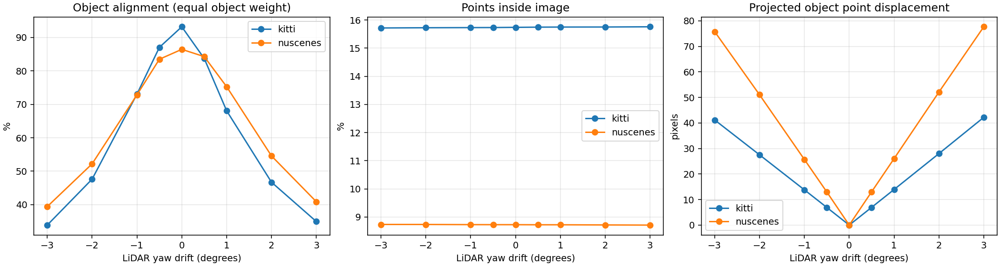

other_axes.png


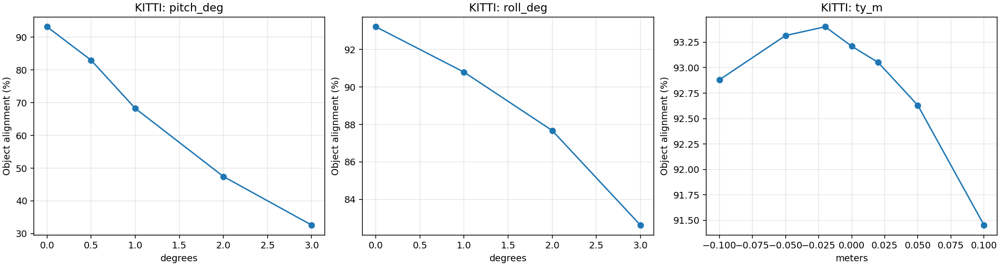

range_class_sweep.png


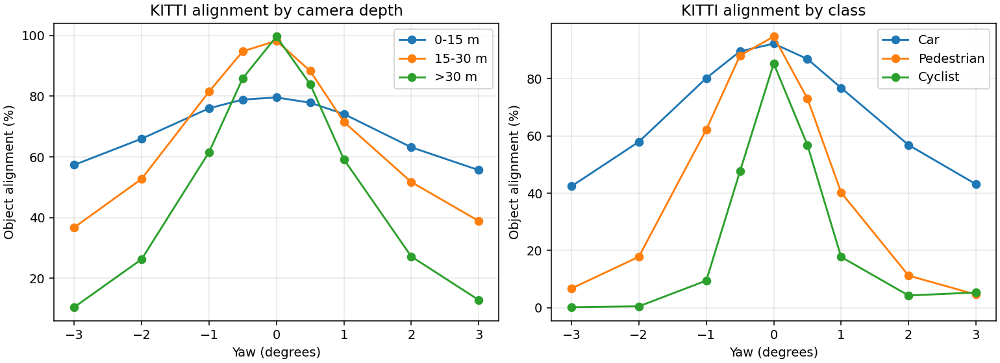

drift_threshold.png


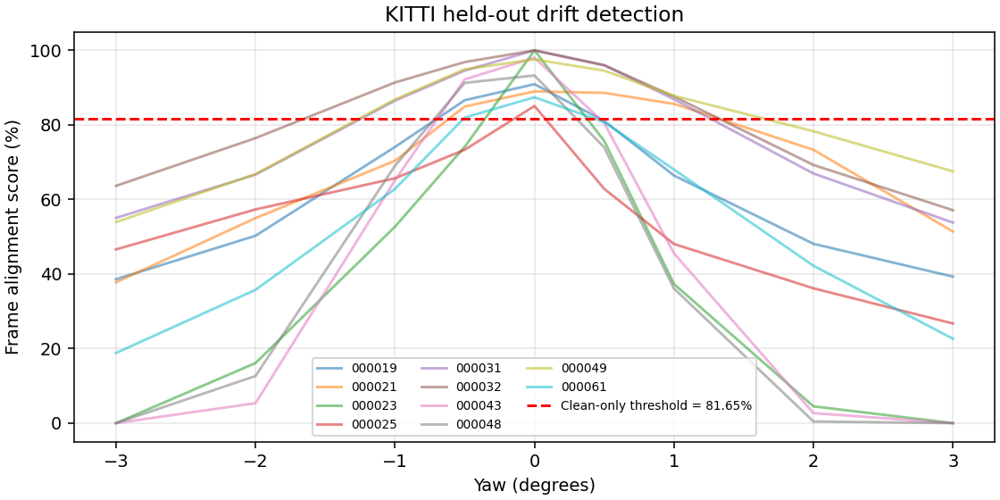

overlay_000011.png


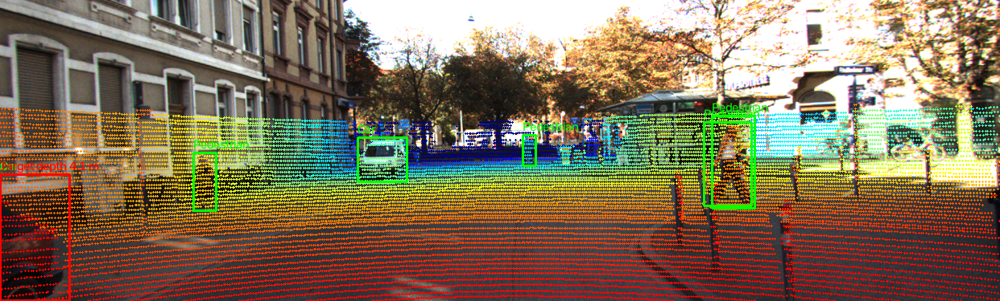

overlay_000019.png


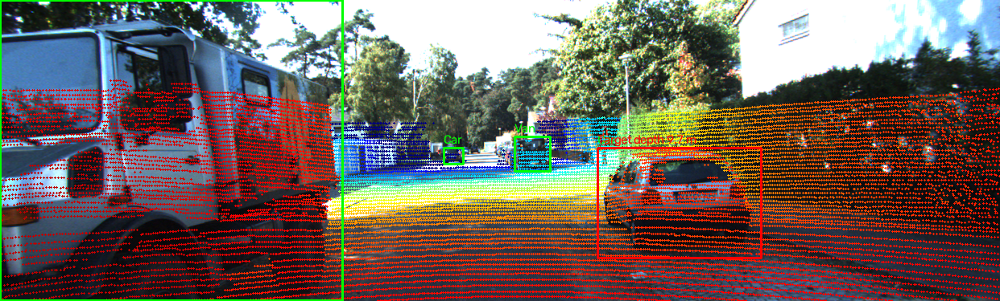

overlay_000004.png


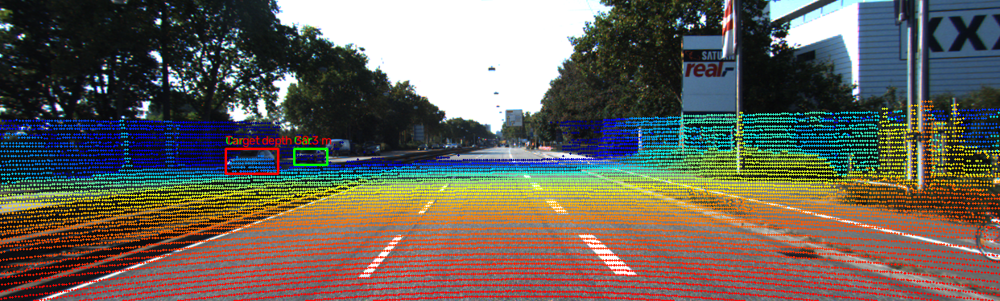

fail_01_large_drift.png


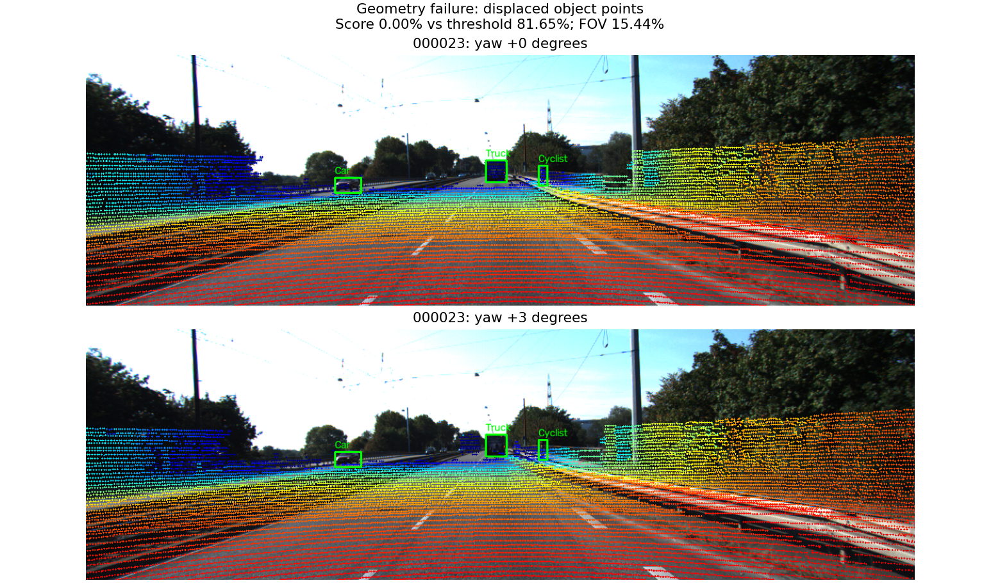

fail_02_score_blind_spot.png


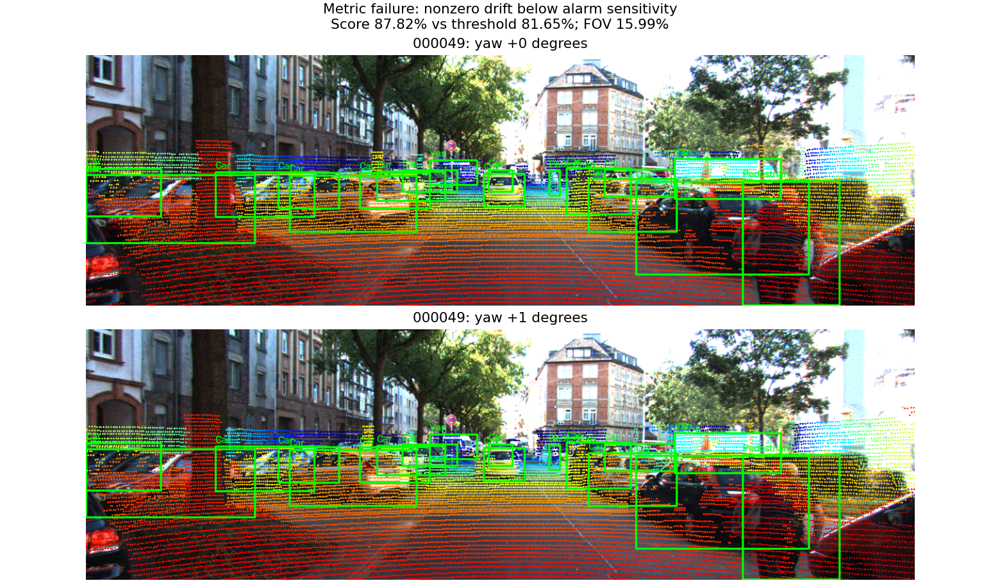

In [13]:
import pandas as pd
from IPython.display import display, Image
summary = pd.read_csv(ROOT / 'results/sweep_summary.csv')
display(summary[summary.factor == 'yaw_deg'])
display(pd.read_csv(ROOT / 'results/detection_summary.csv'))
for name in ['yaw_sweep.png', 'other_axes.png', 'range_class_sweep.png', 'drift_threshold.png',
             'overlay_000011.png', 'overlay_000019.png', 'overlay_000004.png',
             'fail_01_large_drift.png', 'fail_02_score_blind_spot.png']:
    print(name)
    display(Image(filename=str(ROOT / 'results/figures' / name), width=1000))

## 6. Tạo báo cáo từ số liệu Colab và kiểm tra bài
Bổ sung tên lớp nếu đã biết; báo cáo ghi đúng runtime tạo số liệu.

In [ ]:
CLASS_NAME = 'AI20K-T4'
subprocess.run([sys.executable, '-B', '-m', 'src.write_report', '--class-name', CLASS_NAME], check=True)
subprocess.run([sys.executable, '-B', 'tools/check_submission.py'], check=True)
# check_submission scans git-tracked files; also inspect new student artifacts.
artifacts = [ROOT / path for path in STUDENT_FILES] + list((ROOT / 'results').rglob('*'))
assert all(path.stat().st_size <= 20_000_000 for path in artifacts if path.is_file())
from IPython.display import Markdown
display(Markdown((ROOT / 'report/REPORT.md').read_text(encoding='utf-8')))

# Báo cáo Day 6: Độ nhạy của LiDAR–camera projection với calibration drift

- **Họ tên:** Trần Ngọc Khuyến
- **MSSV:** 2A202602682
- **Lớp:** Track 4 — chưa được cung cấp tên lớp cụ thể
- **Link repo:** https://github.com/TrKhuyn/TranNgocKhuyen-2A202602682-Track4-Day21
- **Topic:** A — LiDAR-camera projection QA; Good + khảo sát alignment score/ngưỡng ở mức Advanced.
- **Dataset:** data/synthetic (kiểm tra geometry), data/kitti_mini, data/nuscenes_mini_subset.
- **Các frame đã dùng:** KITTI: 000001, 000004, 000007, 000008, 000009, 000010, 000011, 000012, 000015, 000016, 000019, 000021, 000023, 000025, 000031, 000032, 000043, 000048, 000049, 000061; nuScenes: `scene-0103_000…039`, `scene-1094_000…039`; synthetic: 000000 cho kiểm tra điểm chuẩn.
- **Môi trường tạo số liệu hiện tại:** Google Colab (Linux); Python 3.13.16, NumPy 2.1.3, OpenCV 5.0.0, pandas 2.2.3, matplotlib 3.10.0.

## 1. Claim

Trên 20 frame KITTI, lệch yaw +1° làm alignment trung bình theo object giảm từ **93.21% xuống 68.08%** (−25.13 điểm phần trăm), trong khi tỉ lệ điểm trong FOV chỉ đổi từ 15.74% thành 15.75%.
Ở +3°, alignment còn 34.93%; vì vậy FOV ratio một mình không đủ để kiểm tra calibration.
Đây là kết quả thực nghiệm trên subset, không phải ngưỡng bảo đảm an toàn cho mọi sensor hoặc scene.

## 2. Evidence

Mỗi lần chỉ thay đổi một yếu tố: yaw −3…+3° trên hai dataset; pitch 0/0.5/1/2/3°, roll 0/1/2/3°, translation theo y LiDAR KITTI 0/±2/±5/±10 cm. Seed 42, không có phép lấy mẫu ngẫu nhiên trong benchmark.
Tập điểm object được chọn **một lần** bằng box 3D GT và calibration gốc, cố định qua mọi mức drift; mỗi object có ≥5 điểm, kể cả điểm ra khỏi FOV sau perturb vẫn nằm trong mẫu số.
`alignment = 100 × mean_object(n_points_inside_own_2D_box / n_reference_object_points)`; bảng dùng trung bình theo object, score cảnh báo dùng trung bình object trong từng frame. FOV dùng số điểm XYZ hữu hạn làm mẫu số; CSV còn có micro average theo điểm.

| Yaw (°) | KITTI: alignment (%) | KITTI: FOV (%) | nuScenes: alignment (%) |
|---:|---:|---:|---:|
| -3 | 33.87 | 15.72 | 39.40 |
| -2 | 47.61 | 15.73 | 52.19 |
| -1 | 73.05 | 15.73 | 72.85 |
| -0.5 | 87.05 | 15.73 | 83.49 |
| +0 | 93.21 | 15.74 | 86.46 |
| +0.5 | 83.73 | 15.75 | 84.29 |
| +1 | 68.08 | 15.75 | 75.28 |
| +2 | 46.70 | 15.75 | 54.57 |
| +3 | 34.93 | 15.76 | 40.86 |

![Yaw sweep](../results/figures/yaw_sweep.png)
![Các trục khác](../results/figures/other_axes.png)
![Range và class](../results/figures/range_class_sweep.png)

Demo ở ba độ sâu target khác nhau: `000019`: 9.72 m; `000011`: 4.13 m; `000004`: 38.26 m. Target được đánh dấu đỏ; các box còn lại màu xanh. Màu điểm theo depth của starter: đỏ gần, xanh xa.

![Demo gần](../results/figures/overlay_000011.png)
![Demo trung gian](../results/figures/overlay_000019.png)
![Demo xa](../results/figures/overlay_000004.png)

**Ngưỡng Advanced:** lấy percentile 5 của score clean trên 10 frame KITTI đầu theo frame ID: **81.65%**; alarm khi score thấp hơn ngưỡng. Không dùng frame evaluation hoặc các mức perturb để chọn ngưỡng.
Trên 10 frame còn lại: alarm +1° = 60%, −1° = 70%, clean = 0%; chi tiết trong `results/detection_summary.csv`. Với tập test nhỏ và các perturb của cùng frame, không xem đây là ước lượng độc lập hay bảo đảm tổng quát.

![Score và ngưỡng](../results/figures/drift_threshold.png)

**[B5]** Cùng yaw sweep trên hai dataset thật: bảng trên và `results/sweep_summary.csv` là bằng chứng. KITTI 64 beam, ảnh hẹp 1242×375; nuScenes 32 beam, ảnh 1600×900 và hai scene ngày/đêm. Khác focal length, FOV, object mix và số điểm tạo ra mức dịch pixel/score khác nhau; không quy toàn bộ khác biệt cho số beam.
nuScenes đã bù ego motion nhưng chưa bù chuyển động riêng từng object. Box 2D của loader nuScenes **được sinh từ box 3D**, nên kết quả này là kiểm tra nhạy với perturb trong cùng hình học, không phải đối chiếu annotation 2D độc lập như KITTI.
Nguồn ảnh: **KITTI Vision Benchmark Suite**; dữ liệu nuScenes: **nuScenes (Motional)**.

CSV tái lập: `results/frame_metrics.csv`, `object_metrics.csv`, `sweep_summary.csv`, `drift_detection.csv`, `detection_summary.csv`, `demo_depths.csv`; cấu hình, phiên bản và SHA-256 nằm trong `results/run_metadata.json`.

## 3. Failure case

**Geometry:** frame `000023` ở yaw +3° còn alignment 0.00% và dịch median 37.98 px. Extrinsic sai làm điểm rơi khỏi object; FOV vẫn 15.44% nên không chỉ nhìn tổng số điểm trong ảnh.

![Geometry failure](../results/figures/fail_01_large_drift.png)

**Metric:** frame `000049`, yaw +1° dịch điểm median 14.67 px nhưng score 87.82% vẫn trên ngưỡng 81.65% → bỏ sót drift. Box 2D cho phép sai số vị trí bên trong box; trung bình qua object còn che mất một object bị lệch. Kiểm tra score từng object, displacement và edge alignment để phát hiện.

![Metric failure](../results/figures/fail_02_score_blind_spot.png)

Điểm pixel displacement cần calibration tham chiếu, còn containment score cần box GT và tập điểm đã chọn từ calibration gốc. Cả hai là công cụ QA **offline**, chưa phải bộ phát hiện drift tự động khi chạy thật không có GT.
Object <5 điểm bị loại nên chưa đánh giá được vật cực xa/thưa; occlusion/truncation và box GT vốn có sai số cũng có thể làm score clean thấp. Dùng scene độc lập lớn hơn, score theo class/range và edge alignment để kiểm chứng thêm.

## 4. Khuyến nghị nếu triển khai thật

Use-case: QA sau lắp sensor hoặc sau va chạm nhẹ trên xe ADAS; theo dõi drift trước khi sử dụng kết quả camera–LiDAR fusion.
Log invalid ratio, FOV, alignment theo object/class/range, camera–LiDAR time offset và latency; ảnh overlay cần được giữ ở các frame alarm để review.
Containment tính nhanh nhưng bỏ sót dịch trong box lớn; edge alignment hoặc correspondence độc lập tốn thêm xử lý và dễ nhiễu do texture, ban đêm và occlusion.
Không tự hiệu chỉnh calibration chỉ từ threshold trong lab: cần cảnh báo liên tiếp nhiều frame, kiểm tra chuyển động object, scene đa dạng và quy trình xác nhận calibration.

## 5. Cách chạy lại

Từ thư mục gốc repo đã clone, Python ≥3.10:

```bash
pip install -r requirements.txt
python tools/verify_data.py --data-root data/kitti_mini
python tools/verify_data.py --data-root data/nuscenes_mini_subset
python -m unittest src.test_projection -v
python -m src.topic_a
python -m src.write_report
python tools/check_submission.py
```

**[B4]** Tool dùng lại được: `python -m src.topic_a --help` mô tả mọi tham số và giá trị mặc định; `python -m src.topic_a` chạy toàn bộ thí nghiệm, hoặc thêm `--skip-nuscenes --out-dir results/kitti_only` để chạy KITTI riêng. Bằng chứng: `src/topic_a.py` và CSV/ảnh đã tạo. B4/B5 có thể được chấm tối đa +5 điểm nếu tiêu chí liên quan đạt; không khai báo B1/B2/B3/B6.
**Colab extension:** mở `src/topic_a_colab.ipynb` → Select Kernel → Colab → Auto Connect → Run All. Cell cuối tạo `results.zip` và gửi yêu cầu tải qua widget; nếu trình duyệt/VS Code chặn tải tự động, bấm **Tải results.zip**. ZIP chứa `results/` và REPORT của runtime đó; không cần push code trước khi chạy. Xem `src/COLAB.md` để lấy kết quả về máy.
Notebook sẽ ghi runtime thực vào metadata và tạo lại REPORT từ CSV của runtime đó; không gọi kết quả local là kết quả Colab.
Sáu kiểm tra geometry gồm điểm chuẩn (10,0,0), rigid transform + rectification, cột translation của P2, NaN/Inf/depth/FOV, input rỗng và membership box xoay có bottom-center.

## 6. Khai báo sử dụng AI

| Công cụ | Dùng cho việc gì | Cách kiểm chứng |
|---|---|---|
| Codex | Phân tích đề, hỗ trợ viết projection, benchmark, notebook Colab và báo cáo từ CSV | Kiểm tra geometry độc lập; chạy thật trên dữ liệu gốc, xem overlay/failure và đối chiếu bảng với CSV; ghi đúng runtime trong metadata |

Học viên cần tự đọc code, đối chiếu kết quả và giải thích được metric cùng các failure trước khi nộp/vấn đáp. Thông tin tên lớp cụ thể chưa được cung cấp; cần bổ sung nếu lớp yêu cầu.


## 7. Xuất kết quả về repo local

Cell dưới tạo **results.zip** chứa `results/` và `report/REPORT.md`, rồi gửi yêu cầu tải về máy qua widget.
Nếu tải tự động bị chặn, bấm **Tải results.zip** trong cell; cách dự phòng là **Colab → Contents → results.zip → Download**.
Giải nén vào repo local để thay kết quả local bằng kết quả Colab, rồi Save notebook để giữ outputs trong VS Code.
ZIP được truyền qua widget khi kernel đang kết nối, không nhúng dữ liệu ZIP vào outputs của notebook.


In [15]:
from src.export_results import make_archive, show_download
archive = make_archive(ROOT, '/content/results.zip')
print(f'Download: {archive} ({archive.stat().st_size / 1e6:.1f} MB)')
print('Không commit ZIP; chỉ commit các file đã giải nén và notebook đã Save.')
download_widget = show_download(archive)

Download: /content/results.zip (7.9 MB)
Không commit ZIP; chỉ commit các file đã giải nén và notebook đã Save.


<src.export_results.show_download.<locals>.ResultsDownload object at 0x7cb5812ecc20>